<a href="https://colab.research.google.com/github/BhuvanSaraf/Underwater-Image-Enhancement-UIEB-AI-project-/blob/main/Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Initializations

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import time
import albumentations as A


# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Copy the file to local Colab storage
!cp /content/drive/MyDrive/Train_Val_Dataset/Train_Val_Dataset.zip /content/

# Unzip it quietly (-q)
!unzip -q /content/Train_Val_Dataset.zip -d /content

In [4]:
def load_images_to_numpy(raw_path, ref_path):
    raw_list, ref_list = [], []

    # Filter for image files only
    raw_files = sorted([f for f in os.listdir(raw_path) if f.endswith(('.png'))])
    ref_files = sorted([f for f in os.listdir(ref_path) if f.endswith(('.png'))])

    for r_f, g_f in zip(raw_files, ref_files):
        # Load, resize
        img_raw = cv2.imread(os.path.join(raw_path, r_f))
        img_ref = cv2.imread(os.path.join(ref_path, g_f))
        #color settings?
        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        img_ref = cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB)

        if img_raw is not None and img_ref is not None:
            # Resize and flatten
            raw_flat = cv2.resize(img_raw, (256, 256)) / 255.0
            ref_flat = cv2.resize(img_ref, (256, 256)) / 255.0

            raw_list.append(raw_flat)
            ref_list.append(ref_flat)

    return np.array(raw_list, dtype='float32'), np.array(ref_list, dtype='float32')

X_train, y_train = load_images_to_numpy('/content/Train_Val_Dataset/train/raw', '/content/Train_Val_Dataset/train/reference')
X_val, y_val = load_images_to_numpy('/content/Train_Val_Dataset/val/raw', '/content/Train_Val_Dataset/val/reference')

# Neural Network:

In [5]:
class UnderwaterAutoencoder(nn.Module):
    def __init__(self):
        super(UnderwaterAutoencoder, self).__init__()

        # Encoder: Same as before
        self.encoder = nn.Sequential(
            nn.Linear(196608, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        # Decoder: REMOVE Sigmoid at the end
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), # Re-enable this for stability
            nn.ReLU(),
            nn.Linear(1024, 196608) # Final layer has no activation
        )

    def forward(self, x):
        residual = self.decoder(self.encoder(x))
        out = x + residual
        return torch.clamp(out, 0.0, 1.0)

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UnderwaterAutoencoder().to(device)

In [6]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], additional_targets={'image0': 'image'})

In [13]:
import time
import torch
import numpy as np

# --- Configuration ---
epochs = 100
batch_size = 16
learning_rate = 1e-4
decay = 1e-5

# 1. Ensure validation data is on the correct device
# Note: If memory allows, keep them as tensors. If not, move them inside the loop.
X_val_t = torch.tensor(X_val, dtype=torch.float32).flatten(start_dim=1).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).flatten(start_dim=1).to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)
criterion_mse = nn.MSELoss()

train_losses = []
val_losses = []

total_start_time = time.time()

for epoch in range(epochs):
    epoch_start_time = time.time()

    # Shuffle indices for this epoch
    indices = np.random.permutation(len(X_train))

    model.train()
    running_train_loss = 0.0

    for i in range(0, len(X_train), batch_size):
        batch_indices = indices[i : i + batch_size]

        batch_inputs_list = []
        batch_targets_list = []

        for idx in batch_indices:
            # Apply augmentations
            augmented = transform(image=X_train[idx], target_image=y_train[idx])

            # Flatten and store as numpy first (faster to batch-convert)
            batch_inputs_list.append(augmented['image'].flatten())
            batch_targets_list.append(augmented['target_image'].flatten())

        # Convert list of arrays to a single tensor and move to device ONCE per batch
        inputs = torch.as_tensor(np.array(batch_inputs_list), dtype=torch.float32).to(device)
        targets = torch.as_tensor(np.array(batch_targets_list), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion_mse(outputs, targets)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(X_train)
    train_losses.append(epoch_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for i in range(0, len(X_val_t), batch_size):
            v_inputs = X_val_t[i : i + batch_size]
            v_targets = y_val_t[i : i + batch_size]

            v_outputs = model(v_inputs)
            v_loss = criterion_mse(v_outputs, v_targets)
            running_val_loss += v_loss.item() * v_inputs.size(0)

    epoch_val_loss = running_val_loss / len(X_val_t)
    val_losses.append(epoch_val_loss)

    # Update scheduler
    scheduler.step(epoch_val_loss)

    # Get current LR from optimizer (not the static variable)
    current_lr = optimizer.param_groups[0]['lr']

    epoch_duration = time.time() - epoch_start_time
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Time: {epoch_duration:.2f}s | LR: {current_lr:.2e}")

total_duration = time.time() - total_start_time
print(f"\n--- Training Complete ---")
print(f"Total Execution Time: {total_duration/60:.2f} minutes")

Epoch 1/100 | Train Loss: 0.061970 | Val Loss: 0.021951 | Time: 8.64s | LR: 1.00e-04
Epoch 2/100 | Train Loss: 0.059708 | Val Loss: 0.023251 | Time: 8.60s | LR: 1.00e-04
Epoch 3/100 | Train Loss: 0.059600 | Val Loss: 0.020852 | Time: 8.40s | LR: 1.00e-04
Epoch 4/100 | Train Loss: 0.061345 | Val Loss: 0.021859 | Time: 8.64s | LR: 1.00e-04
Epoch 5/100 | Train Loss: 0.061172 | Val Loss: 0.021861 | Time: 8.44s | LR: 1.00e-04
Epoch 6/100 | Train Loss: 0.062254 | Val Loss: 0.020843 | Time: 8.59s | LR: 1.00e-04
Epoch 7/100 | Train Loss: 0.056650 | Val Loss: 0.021624 | Time: 8.48s | LR: 1.00e-04
Epoch 8/100 | Train Loss: 0.056276 | Val Loss: 0.021511 | Time: 8.30s | LR: 1.00e-04
Epoch 9/100 | Train Loss: 0.057762 | Val Loss: 0.020559 | Time: 8.46s | LR: 1.00e-04
Epoch 10/100 | Train Loss: 0.057508 | Val Loss: 0.025200 | Time: 8.34s | LR: 1.00e-04
Epoch 11/100 | Train Loss: 0.056110 | Val Loss: 0.021656 | Time: 8.40s | LR: 1.00e-04
Epoch 12/100 | Train Loss: 0.056590 | Val Loss: 0.021022 | Time

In [14]:
def calculate_metrics(target, prediction):
    # Reshape back to (Batch, H, W, C) for visualization/metrics
    target = target.reshape(-1, 256, 256, 3)
    prediction = prediction.reshape(-1, 256, 256, 3)

    psnrs = []
    ssims = []

    for i in range(target.shape[0]):
        # PSNR
        p = psnr_metric(target[i], prediction[i], data_range=1.0)
        psnrs.append(p)

        # SSIM
        s = ssim_metric(target[i], prediction[i], data_range=1.0, channel_axis=-1)
        ssims.append(s)

    return np.mean(psnrs), np.mean(ssims)

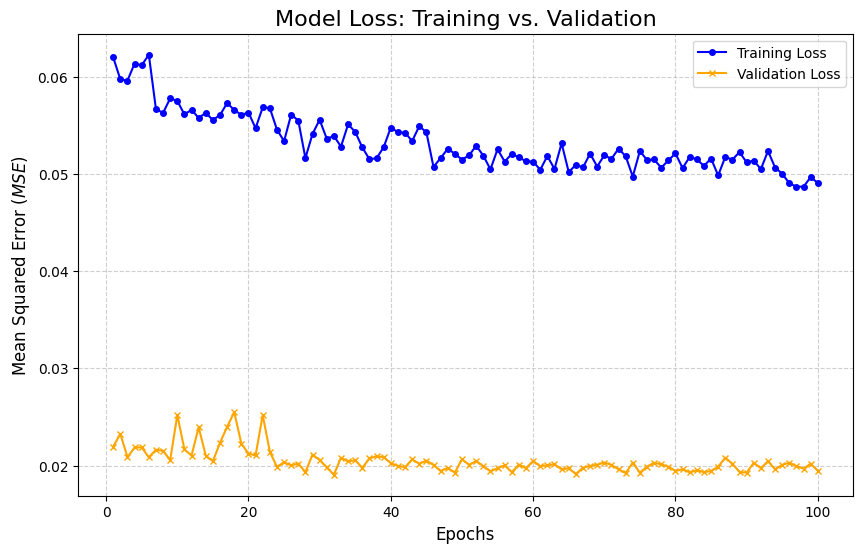

In [15]:
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, val_losses, label='Validation Loss', color='orange', marker='x', markersize=4)
plt.title('Model Loss: Training vs. Validation', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error ($MSE$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
# 1. Put model in evaluation mode
model.eval()

# 3. Predict without calculating gradients
with torch.no_grad():
    preds_t = model(X_val_t)

# 4. Move back to CPU and convert to NumPy for your metrics function
preds = preds_t.cpu().numpy()

# 5. Run the metrics
avg_psnr, avg_ssim = calculate_metrics(y_val, preds)

print(f"Validation PSNR: {avg_psnr:.2f}")
print(f"Validation SSIM: {avg_ssim:.4f}")

Validation PSNR: 18.21
Validation SSIM: 0.7121


In [11]:
# Save to Google Drive
torch.save(model.state_dict(), '/content/drive/MyDrive/AI_project/underwater_model1.pth')

In [12]:
loss_history = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses
})

loss_history.to_csv('/content/drive/MyDrive/AI_project/loss_results1.csv', index=False)